In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/newweights-pkl/Indian_s2vnet_p7_96.43_epoch480.pkl
/kaggle/input/indian-pines-19/S2VNet-main/flowchart.png
/kaggle/input/indian-pines-19/S2VNet-main/LICENSE
/kaggle/input/indian-pines-19/S2VNet-main/README.md
/kaggle/input/indian-pines-19/S2VNet-main/s2vnet_model.py
/kaggle/input/indian-pines-19/S2VNet-main/utils.py
/kaggle/input/indian-pines-19/S2VNet-main/dataset.py
/kaggle/input/indian-pines-19/S2VNet-main/demo.py
/kaggle/input/indian-pines-19/S2VNet-main/model/retentive.py
/kaggle/input/indian-pines-19/S2VNet-main/data/IndianPine.mat


In [2]:
import sys

In [3]:
sys.path.append('/kaggle/input/indian-pines-19')

In [4]:
print(sys.path)

['/kaggle/working', '/kaggle/lib/kagglegym', '/kaggle/lib', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.10/dist-packages/IPython/extensions', '/usr/local/lib/python3.10/dist-packages/setuptools/_vendor', '/root/.ipython', '/kaggle/input/indian-pines-19']


In [5]:
import os
import shutil
import sys

# ✅ Read-only input directory
input_dir = '/kaggle/input/indian-pines-19/S2VNet-main'

# ✅ Writable working directory
working_dir = '/kaggle/working/S2VNet-main'

# ✅ Step 1: Copy the repo
if not os.path.exists(working_dir):
    shutil.copytree(input_dir, working_dir)
    print(f"✅ Copied S2VNet-main to: {working_dir}")
else:
    print(f"📂 Directory already exists: {working_dir}")

# ✅ Step 2: Add __init__.py to model/ so it becomes a package
model_dir = os.path.join(working_dir, 'model')
init_path = os.path.join(model_dir, '__init__.py')
if not os.path.exists(init_path):
    with open(init_path, 'w') as f:
        f.write("# makes model a package")
    print(f"✅ Created __init__.py at: {init_path}")
else:
    print(f"ℹ️ __init__.py already exists: {init_path}")

# ✅ Step 3: Add working_dir and model folder to sys.path
if working_dir not in sys.path:
    sys.path.append(working_dir)
if model_dir not in sys.path:
    sys.path.append(model_dir)

print("📌 sys.path updated with:")
print("  -", working_dir)
print("  -", model_dir)

# ✅ Step 4: Check what’s inside model/
print("\n📁 Contents of model/:")
print(os.listdir(model_dir))

# ✅ Step 5: Find S2VNet class
!grep -rnw '/kaggle/working/S2VNet-main/' -e 'class S2VNet'

✅ Copied S2VNet-main to: /kaggle/working/S2VNet-main
✅ Created __init__.py at: /kaggle/working/S2VNet-main/model/__init__.py
📌 sys.path updated with:
  - /kaggle/working/S2VNet-main
  - /kaggle/working/S2VNet-main/model

📁 Contents of model/:
['retentive.py', '__init__.py']
/kaggle/working/S2VNet-main/s2vnet_model.py:11:class S2VNet(nn.Module):


In [6]:
#dataset
import torch
import torch.utils.data as Data

from scipy.io import loadmat
import numpy as np
import os #changed
def prepare_dataset(args, samples_type='ratio'):
    # prepare data
    if args.dataset == 'Indian':
        print("📂 Trying to load:", '/kaggle/input/indian-pines-19/data/IndianPine.mat')

        data = loadmat('/kaggle/input/indian-pines-19/S2VNet-main/data/IndianPine.mat')
        print("📂 Loading .mat from:", data_path)  # ✅ debug line
        #changed
        # data_path = os.path.join(working_dir, 'data', 'IndianPine.mat')
        # print("📂 Loading .mat from:", data_path)  # ✅ debug line
        # data = loadmat(data_path)
        #changed
        TR = data['TR']
        TE = data['TE']
        input = data['input'] #(145,145,200)
    elif args.dataset == 'Berlin':
        data = loadmat('./data/Berlin/data_HS_LR.mat')
        data_train = loadmat('./data/Berlin/TrainImage.mat')
        data_test = loadmat('./data/Berlin/TestImage.mat')
        TR = data_train['TrainImage']
        TE = data_test['TestImage']
        input = data['data_HS_LR'] #(1723,476,244)
    elif args.dataset == 'Augsburg':
        data = loadmat('./data/Augsburg/data_HS_LR.mat')
        data_train = loadmat('./data/Augsburg/TrainImage.mat')
        data_test = loadmat('./data/Augsburg/TestImage.mat')
        TR = data_train['TrainImage']
        TE = data_test['TestImage']
        input = data['data_HS_LR'] #(332,485,180)
    else:
        raise ValueError("Unknown dataset")

    label = TR + TE
    num_classes = np.max(TR)
    # train data change to the ratio of train samples
    if samples_type == 'ratio':
        training_ratio = 1# range from 0 to 1, e.g. training_ratio=0.5 means 50% training samples.
        print('Train data change to the ratio of train samples: {}'.format(training_ratio))
        train_idx, TR = split_train_data_clssnum(TR, num_classes, training_ratio)

    # normalize data by band norm
    input_normalize = np.zeros(input.shape)
    for i in range(input.shape[2]):
        input_max = np.max(input[:,:,i])
        input_min = np.min(input[:,:,i])
        input_normalize[:,:,i] = (input[:,:,i]-input_min)/(input_max-input_min)
    # data size
    height, width, band = input.shape
    print("height={0},width={1},band={2}".format(height, width, band))
    #-------------------------------------------------------------------------------
    # obtain train and test data
    total_pos_train, total_pos_test, total_pos_true, number_train, number_test, number_true = chooose_train_and_test_point(TR, TE, label, num_classes)
    mirror_image = mirror_hsi(height, width, band, input_normalize, patch=args.patches)
    x_train_band, x_test_band, x_true_band = train_and_test_data(mirror_image, band, total_pos_train, total_pos_test, patch=args.patches, true_point=total_pos_true)
    y_train, y_test, y_true = train_and_test_label(number_train, number_test, num_classes, number_true)
    #-------------------------------------------------------------------------------
    # load data
    x_train=torch.from_numpy(x_train_band.transpose(0,3,2,1)).type(torch.FloatTensor) #[695, 200, 7, 7]
    y_train=torch.from_numpy(y_train).type(torch.LongTensor) #[695]
    Label_train=Data.TensorDataset(x_train, y_train)
    label_train_loader=Data.DataLoader(Label_train,batch_size=args.batch_size,shuffle=True)

    x_test=torch.from_numpy(x_test_band.transpose(0,3,2,1)).type(torch.FloatTensor) # [9671, 200, 7, 7]
    y_test=torch.from_numpy(y_test).type(torch.LongTensor) # [9671]
    Label_test=Data.TensorDataset(x_test, y_test)
    label_test_loader=Data.DataLoader(Label_test,batch_size=args.batch_size,shuffle=True)

    x_true=torch.from_numpy(x_true_band.transpose(0,3,2,1)).type(torch.FloatTensor)
    y_true=torch.from_numpy(y_true).type(torch.LongTensor)
    Label_true=Data.TensorDataset(x_true, y_true)
    label_true_loader=Data.DataLoader(Label_true,batch_size=args.batch_size,shuffle=False)
    return label_train_loader, label_test_loader, label_true_loader, band, height, width, num_classes, label, total_pos_true

# split dataset by training set ratio
def split_train_data_clssnum(gt, num_classes, train_num_ratio):
    train_idx = []

    TR = np.zeros_like(gt)
    for i in range(num_classes):
        idx = np.argwhere(gt == i + 1)
        samplesCount = len(idx)
        # print("Class", i, ":", samplesCount)
        sample_num = np.ceil(train_num_ratio * samplesCount).astype('int32')
        train_idx.append(idx[: sample_num])

        for j in range(sample_num):
            TR[idx[j,0], idx[j,1]] = i + 1

    train_idx = np.concatenate(train_idx, axis=0)
    return train_idx, TR

# 定位训练和测试样本
def chooose_train_and_test_point(train_data, test_data, true_data, num_classes):
    number_train = []
    pos_train = {}
    number_test = []
    pos_test = {}
    number_true = []
    pos_true = {}
    #-------------------------for train data------------------------------------
    for i in range(num_classes):
        each_class = []
        each_class = np.argwhere(train_data==(i+1))
        number_train.append(each_class.shape[0])
        pos_train[i] = each_class

    total_pos_train = pos_train[0]
    for i in range(1, num_classes):
        total_pos_train = np.r_[total_pos_train, pos_train[i]] #(695,2)
    total_pos_train = total_pos_train.astype(int)
    #--------------------------for test data------------------------------------
    for i in range(num_classes):
        each_class = []
        each_class = np.argwhere(test_data==(i+1))
        number_test.append(each_class.shape[0])
        pos_test[i] = each_class

    total_pos_test = pos_test[0]
    for i in range(1, num_classes):
        total_pos_test = np.r_[total_pos_test, pos_test[i]] #(9671,2)
    total_pos_test = total_pos_test.astype(int)
    #--------------------------for true data------------------------------------
    for i in range(num_classes+1):
        each_class = []
        each_class = np.argwhere(true_data==i)
        number_true.append(each_class.shape[0])
        pos_true[i] = each_class

    total_pos_true = pos_true[0]
    for i in range(1, num_classes+1):
        total_pos_true = np.r_[total_pos_true, pos_true[i]]
    total_pos_true = total_pos_true.astype(int)

    return total_pos_train, total_pos_test, total_pos_true, number_train, number_test, number_true

# 边界拓展：镜像
def mirror_hsi(height, width, band, input_normalize, patch=5):
    padding=patch//2
    mirror_hsi=np.zeros((height+2*padding,width+2*padding,band),dtype=float)
    #中心区域
    mirror_hsi[padding:(padding+height),padding:(padding+width),:]=input_normalize
    #左边镜像
    for i in range(padding):
        mirror_hsi[padding:(height+padding),i,:]=input_normalize[:,padding-i-1,:]
    #右边镜像
    for i in range(padding):
        mirror_hsi[padding:(height+padding),width+padding+i,:]=input_normalize[:,width-1-i,:]
    #上边镜像
    for i in range(padding):
        mirror_hsi[i,:,:]=mirror_hsi[padding*2-i-1,:,:]
    #下边镜像
    for i in range(padding):
        mirror_hsi[height+padding+i,:,:]=mirror_hsi[height+padding-1-i,:,:]

    print("**************************************************")
    print("patch is : {}".format(patch))
    print("mirror_image shape : [{0},{1},{2}]".format(mirror_hsi.shape[0],mirror_hsi.shape[1],mirror_hsi.shape[2]))
    print("**************************************************")
    return mirror_hsi

# 获取patch的图像数据
def gain_neighborhood_pixel(mirror_image, point, i, patch=5):
    x = point[i,0]
    y = point[i,1]
    temp_image = mirror_image[x:(x+patch),y:(y+patch),:]
    return temp_image

# 汇总训练数据和测试数据
def train_and_test_data(mirror_image, band, train_point, test_point, patch=5, true_point=None):
    x_train = np.zeros((train_point.shape[0], patch, patch, band), dtype=float)
    x_test = np.zeros((test_point.shape[0], patch, patch, band), dtype=float)

    for i in range(train_point.shape[0]):
        x_train[i,:,:,:] = gain_neighborhood_pixel(mirror_image, train_point, i, patch)
    for j in range(test_point.shape[0]):
        x_test[j,:,:,:] = gain_neighborhood_pixel(mirror_image, test_point, j, patch)

    print("x_train shape = {}, type = {}".format(x_train.shape,x_train.dtype))
    print("x_test  shape = {}, type = {}".format(x_test.shape,x_test.dtype))
    # if true_point.all() != None:
    if true_point is not None:
    # if true_point is not None:
    
        x_true = np.zeros((true_point.shape[0], patch, patch, band), dtype=float)
        for k in range(true_point.shape[0]):
            x_true[k,:,:,:] = gain_neighborhood_pixel(mirror_image, true_point, k, patch)
        print("x_true  shape = {}, type = {}".format(x_true.shape,x_test.dtype))
        print("**************************************************")
        return x_train, x_test, x_true
    else:
        print("**************************************************")
        return x_train, x_test

# 标签y_train, y_test
def train_and_test_label(number_train, number_test, num_classes, number_true=None):
    y_train = []
    y_test = []
    for i in range(num_classes):
        for j in range(number_train[i]):
            y_train.append(i)
        for k in range(number_test[i]):
            y_test.append(i)
    y_train = np.array(y_train)
    y_test = np.array(y_test)
    print("y_train: shape = {} ,type = {}".format(y_train.shape,y_train.dtype))
    print("y_test: shape = {} ,type = {}".format(y_test.shape,y_test.dtype))

    if number_true != None:
        y_true = []
        for i in range(num_classes+1):
            for j in range(number_true[i]):
                y_true.append(i)
        y_true = np.array(y_true)
        print("y_true: shape = {} ,type = {}".format(y_true.shape,y_true.dtype))
        print("**************************************************")
        return y_train, y_test, y_true
    else:
        print("**************************************************")
        return y_train, y_test

In [7]:
#s2vnet_model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init
from model.retentive import VisRetNet
from einops import rearrange, repeat
import numpy as np
import math

class S2VNet(nn.Module):
    """
    Subpixel spectral variability network for hyperspectral image classification
    """
    def __init__(self, band, num_classes, patch_size):
        super(S2VNet, self).__init__()
        self.num_classes = num_classes
        self.patch_size = patch_size
        self.band = band
        # unmixing module
        self.unmix_encoder = nn.Sequential(
            nn.Conv2d(band, band//2, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(band//2),
            nn.ReLU(),
            nn.Conv2d(band//2, band//4, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(band//4),
            nn.ReLU(),
            nn.Conv2d(band//4, num_classes, kernel_size=1, stride=1, padding=0)
        )
        self.unmix_decoder = nn.Sequential(
            nn.Conv2d(num_classes, band*2, kernel_size=1, stride=1, bias=False),
            nn.ReLU()
        )
        self.unmix_decoder_nonlinear = nn.Sequential(
            nn.Conv2d(band*2, band, kernel_size=1, stride=1, bias=True),
            nn.Sigmoid(),
            nn.Conv2d(band, band, kernel_size=1, stride=1, bias=True),
        )

        # pixel-level classifier
        self.cls = VisRetNet(in_chans=band, num_classes=num_classes, embed_dims=[32])
        # endmember variability modeling
        z_dim = 4
        self.var_encoder_share = nn.Sequential(
            nn.Linear(num_classes, num_classes),
            nn.BatchNorm1d(num_classes),
            nn.ReLU(),
        )
        self.var_encoder_sep1 = nn.Linear(num_classes, z_dim)
        self.var_encoder_sep2 = nn.Linear(num_classes, z_dim)
        self.var_decoder = nn.Sequential(
            nn.Linear(z_dim, 96),
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.Linear(96, num_classes**2),
            nn.ReLU(),
        )

        self.perturb_encoder = nn.Sequential(
            nn.Linear(num_classes, num_classes),
            nn.BatchNorm1d(num_classes),
            nn.ReLU(),
        )
        # fusion module
        self.conv = nn.Sequential(
            nn.Conv2d(num_classes, num_classes, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(num_classes),
            nn.ReLU(),
        )
        self.feature_size = self._get_final_flattened_size()
        self.fc = nn.Linear(self.feature_size, num_classes)

        self.fc_2 = nn.Linear(num_classes*2, num_classes)
        self.relu = nn.ReLU()

    def _get_final_flattened_size(self):
        with torch.no_grad():
            x = torch.zeros((1, self.num_classes, self.patch_size, self.patch_size))
            x = self.conv(x)
            _, c, w, h = x.size()
            return c * w * h + self.num_classes

    def reparameterize(self, mu, log_var):
        std = (log_var * 0.5).exp()
        eps = torch.randn(mu.shape).cuda()
        return mu + eps * std

    def forward(self, x, output_abu=False):
   
           #print("Input x:", x.shape)

           abu = self.unmix_encoder(x)
          # print("abu (after unmix_encoder):", abu.shape)

           re_unmix = self.unmix_decoder(abu)
           #print("re_unmix (after unmix_decoder):", re_unmix.shape)

           re_unmix_nonlinear = self.unmix_decoder_nonlinear(re_unmix)
          # print("re_unmix_nonlinear (after nonlinear decoder):", re_unmix_nonlinear.shape)

           feature_cls = self.cls(x)
           #print("feature_cls (from VisRetNet):", feature_cls.shape)

           abu = abu.abs()
           abu = abu / abu.sum(1).unsqueeze(1)
           #print("abu (after normalization):", abu.shape)

           edm_weight = self.unmix_decoder[0].weight.squeeze()
           #print("edm_weight:", edm_weight.shape)

           edm_var = self.var_encoder_share(edm_weight)
           #print("edm_var:", edm_var.shape)

           edm_var_1 = self.var_encoder_sep1(edm_var)
           edm_var_2 = self.var_encoder_sep2(edm_var)
          # print("edm_var_1 (mu):", edm_var_1.shape)
           #print("edm_var_2 (log_var):", edm_var_2.shape)

           edm_reparam = self.reparameterize(edm_var_1, edm_var_2)
           #print("edm_reparam:", edm_reparam.shape)

           edm_var_de = self.var_decoder(edm_reparam)
           edm_var_de = edm_var_de.view([-1, self.num_classes, self.num_classes])
           #print("edm_var_de (decoded variability):", edm_var_de.shape)

           edm_per = self.perturb_encoder(edm_weight)
           edm_per_tensor = edm_per.view([edm_weight.shape[0], self.num_classes, 1])
           #print("edm_per_tensor:", edm_per_tensor.shape)

           edm_weight_tensor = edm_weight.view([edm_weight.shape[0], self.num_classes, 1])
           edm_weight_new = torch.sigmoid(edm_var_de @ edm_weight_tensor + edm_per_tensor)
           edm_weight_new = edm_weight_new.view([edm_weight.shape[0], self.num_classes, 1, 1])
           #print("edm_weight_new:", edm_weight_new.shape)

           self.unmix_decoder[0].weight = nn.Parameter(edm_weight_new)

           feature_abu = self.conv(abu)
           #print("feature_abu (after fusion conv):", feature_abu.shape)

           abu_v = feature_abu.reshape(x.shape[0], -1)
           #print("abu_v (flattened):", abu_v.shape)

           edm = edm_weight_new[0:self.band, :] + edm_weight_new[self.band:self.band*2, :]
           edm = edm.squeeze()
           #print("edm (sum of subpixel bases):", edm.shape)

           output_linear = re_unmix[:, 0:self.band] + re_unmix[:, self.band:self.band*2]
           re_unmix_out = re_unmix_nonlinear + output_linear
           re_unmix_out = re_unmix_out.view([re_unmix.shape[0], self.band, -1])
           #print("re_unmix_out (final output):", re_unmix_out.shape)

           center_pixel = torch.mean(re_unmix_out, dim=-1)
           #print("center_pixel:", center_pixel.shape)

           cos_value = torch.matmul(center_pixel, edm)
           edm_norm = torch.norm(center_pixel)
           center_pixel_norm = torch.norm(center_pixel)
           cos_value = cos_value / (edm_norm * center_pixel_norm)
           print("cos_value (cosine similarity):", cos_value.shape)

           feature_fuse = torch.cat([abu_v, feature_cls], dim=1)
           #print("feature_fuse (abu + cls):", feature_fuse.shape)

           output_cls = self.fc(feature_fuse)
           output_cls = self.relu(output_cls)
           #print("output_cls (after fc & relu):", output_cls.shape)

           output_cls = torch.cat([output_cls, cos_value], dim=1)
           #print("output_cls (after concat with cos_value):", output_cls.shape)

           output_cls = self.fc_2(output_cls)
           #print("output_cls (final):", output_cls.shape)

           if output_abu:
               return re_unmix_nonlinear, re_unmix, output_cls, feature_abu
           else:
               return re_unmix_nonlinear, re_unmix, output_cls, edm_var_1, edm_var_2, feature_abu, edm_per


/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Train data change to the ratio of train samples: 1
height=145,width=145,band=200
**************************************************
patch is : 7
mirror_image shape : [151,151,200]
**************************************************
x_train shape = (695, 7, 7, 200), type = float64
x_test  shape = (9671, 7, 7, 200), type = float64
x_true  shape = (21025, 7, 7, 200), type = float64
**************************************************
y_train: shape = (695,) ,type = int64
y_test: shape = (9671,) ,type = int64
y_true: shape = (21025,) ,type = int64
**************************************************
Model Name: s2vnet
****************start_test*******************

*********************loading_weights**********************



<ipython-input-8-467a5d1c3d14>:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/kaggle/input/newweights-pkl/Indian_s2vnet_p7_96.43_epoch

****************test_epoch***********************

Overall Accuracy (OA): 0.9667
Average Accuracy (AA): 0.9795
Kappa Coefficient: 0.9621


<ipython-input-8-467a5d1c3d14>:226: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/kaggle/input/newweights-pkl/Indian_s2vnet_p7_96.43_epoch

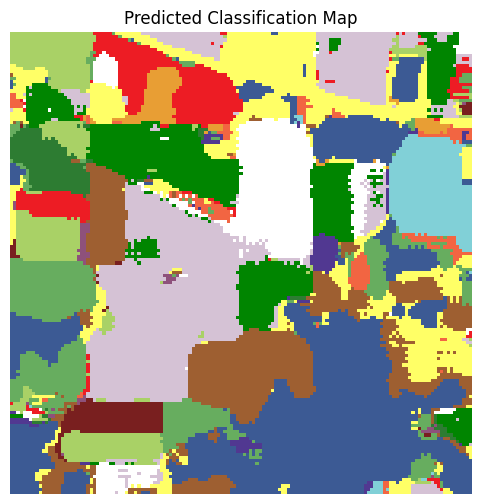

Final result:
OA: 0.9667 | AA: 0.9795 | Kappa: 0.9621
0.9794532851615902
**************************************************
Best Epoch: 000 | Best OA: 0.0000 | Best AA: 0.0000 | Best Kappa: 0.0000
None
**************************************************
Parameter:
fix_random: True
gpu_id: 1
seed: 0
dataset: Indian
flag_test: test
model_name: s2vnet
batch_size: 64
test_freq: 5
patches: 7
epoches: 500
learning_rate: 0.001
gamma: 0.9
weight_decay: 0


In [8]:
#demo
#changed
import sys
sys.path.append('/kaggle/input/indian-pines-19/S2VNet-main')  # ✅ Add this to fix import path
#changed
import torch
import argparse
import torch.nn as nn
import torch.utils.data as Data
import torch.backends.cudnn as cudnn
from scipy.io import savemat
#changed
from scipy.io import loadmat
from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import classification_report
#changed
from torch import optim
from s2vnet_model import S2VNet
from utils import AvgrageMeter, accuracy, output_metric, NonZeroClipper, print_args
from dataset import prepare_dataset
import numpy as np
import time
import os
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

parser = argparse.ArgumentParser("HSI")
parser.add_argument('--fix_random', action='store_true', default=True, help='fix randomness')
parser.add_argument('--gpu_id', default='1', help='gpu id')
parser.add_argument('--seed', type=int, default=0, help='number of seed')
parser.add_argument('--dataset', choices=['Indian', 'Berlin', 'Augsburg'], default='Indian', help='dataset to use')
parser.add_argument('--flag_test', choices=['test', 'train'], default='test', help='testing mark')
parser.add_argument('--model_name', choices=['s2vnet'], default='s2vnet', help='S2VNet')
parser.add_argument('--batch_size', type=int, default=64, help='number of batch size')
parser.add_argument('--test_freq', type=int, default=5, help='number of evaluation')
parser.add_argument('--patches', type=int, default=7, help='number of patches')
parser.add_argument('--epoches', type=int, default=500, help='epoch number')
parser.add_argument('--learning_rate', type=float, default=1e-3, help='learning rate')
parser.add_argument('--gamma', type=float, default=0.9, help='gamma')
parser.add_argument('--weight_decay', type=float, default=0, help='weight_decay')
# args = parser.parse_args() changed
args, _ = parser.parse_known_args()


def train_epoch(model, train_loader, criterion, optimizer):
    objs = AvgrageMeter()
    top1 = AvgrageMeter()
    tar = np.array([])
    pre = np.array([])
    for batch_idx, (batch_data, batch_target) in enumerate(train_loader):
        batch_data = batch_data.cuda()
        batch_target = batch_target.cuda()

        optimizer.zero_grad()
        if 's2vnet' in args.model_name:
            re_unmix_nonlinear, re_unmix, batch_pred, edm_var_1, edm_var_2, feature_abu, edm_per = model(batch_data)

            band = re_unmix.shape[1] // 2  # 2 represents the number of decoder layer
            output_linear = re_unmix[:,0:band] + re_unmix[:,band:band*2]
            re_unmix = re_unmix_nonlinear + output_linear

            # compute kl loss
            kl_div = -0.5 * (edm_var_2 + 1 - edm_var_1 ** 2 - edm_var_2.exp())
            kl_div = kl_div.sum() / batch_pred.shape[0]
            kl_div = torch.max(kl_div, torch.tensor(0).cuda())

            # compute tv loss
            edm_per_diff = edm_per[1:, :] - edm_per[:(edm_per.shape[0] - 1), :]
            edm_per_diff = edm_per_diff.abs()
            loss_tv = edm_per_diff.mean()  # endmember tv_loss

            b_x, h_x, w_x = feature_abu.shape[0], feature_abu.shape[-2], feature_abu.shape[-1]
            h_tv = torch.pow((feature_abu[:, :, 1:, :] - feature_abu[:, :, :h_x - 1, :]), 2).sum()
            w_tv = torch.pow((feature_abu[:, :, :, 1:] - feature_abu[:, :, :, :w_x - 1]), 2).sum()
            loss_tv_abu = (h_tv + w_tv) / (b_x * 2 * h_x * w_x)  # abundance tv_loss

            sad_loss = torch.mean(torch.acos(torch.sum(batch_data * re_unmix, dim=1)/
                        (torch.norm(re_unmix, dim=1, p=2) * torch.norm(batch_data, dim=1, p=2)+1e-5)))
            loss = criterion(batch_pred, batch_target) + sad_loss + 0.01 * kl_div + 0.01 * loss_tv + 0.01 * loss_tv_abu
        else:
            batch_pred = model(batch_data)
            loss = criterion(batch_pred, batch_target)
        loss.backward()
        optimizer.step()

        prec1, t, p = accuracy(batch_pred, batch_target, topk=(1,))
        n = batch_data.shape[0]
        objs.update(loss.data, n)
        top1.update(prec1[0].data, n)
        tar = np.append(tar, t.data.cpu().numpy())
        pre = np.append(pre, p.data.cpu().numpy())
    return top1.avg, objs.avg, tar, pre

def valid_epoch(model, valid_loader, criterion, optimizer):
    objs = AvgrageMeter()
    top1 = AvgrageMeter()
    tar = np.array([])
    pre = np.array([])
    for batch_idx, (batch_data, batch_target) in enumerate(valid_loader):
        batch_data = batch_data.cuda()
        batch_target = batch_target.cuda()

        if 's2vnet' in args.model_name:
            re_unmix_nonlinear, re_unmix, batch_pred, edm_var_1, edm_var_2, _, _ = model(batch_data)

            band = re_unmix.shape[1]//2  # 2 represents the number of decoder layer
            output_linear = re_unmix[:,0:band] + re_unmix[:,band:band*2]
            re_unmix = re_unmix_nonlinear + output_linear

            sad_loss = torch.mean(torch.acos(torch.sum(batch_data * re_unmix, dim=1)/
                        (torch.norm(re_unmix, dim=1, p=2) * torch.norm(batch_data, dim=1, p=2))))
            loss = criterion(batch_pred, batch_target) + sad_loss
        else:
            batch_pred = model(batch_data)
            loss = criterion(batch_pred, batch_target)

        prec1, t, p = accuracy(batch_pred, batch_target, topk=(1,))
        n = batch_data.shape[0]
        objs.update(loss.data, n)
        top1.update(prec1[0].data, n)
        tar = np.append(tar, t.data.cpu().numpy())
        pre = np.append(pre, p.data.cpu().numpy())
    return tar, pre

def test_epoch(model, test_loader):
    pre = np.array([])
    for batch_idx, (batch_data, batch_target) in enumerate(test_loader):
        batch_data = batch_data.cuda()
        batch_target = batch_target.cuda()

        if args.model_name == 's2vnet':
            re_unmix_nonlinear, re_unmix, batch_pred, edm_var_1, edm_var_2, _, _ = model(batch_data)
        else:
            batch_pred = model(batch_data)

        _, pred = batch_pred.topk(1, 1, True, True)
        pp = pred.squeeze()
        pre = np.append(pre, pp.data.cpu().numpy())

    return pre

def main():
      #changed
    best_epoch = 0  # or None or -1, depending on your use case
    best_OA = 0  # or -1, depending on your logic
    best_AA = 0  # or -1 if you're comparing negative values
    best_Kappa = 0  # or -1 if needed
    best_epoch_Kappa = 0  # if you're tracking epoch too
    best_each_AA = None  # or [0.0] * num_classes if it's a list of per-class accuracies
    #
    os.environ["CUDA_VISIBLE_DEVICES"] = str(args.gpu_id)

    if args.fix_random:
        np.random.seed(args.seed)
        torch.manual_seed(args.seed)
        torch.cuda.manual_seed(args.seed)
        cudnn.deterministic = True
        cudnn.benchmark = False
    else:
        cudnn.benchmark = True

    ## prepare dataset
    label_train_loader, label_test_loader, label_true_loader, band, height, width, num_classes, label, total_pos_true = prepare_dataset(args)
    # create model
    if args.model_name == 's2vnet':
        model = S2VNet(band, num_classes, args.patches)
    else:
        raise KeyError("{} model is unknown.".format(args.model_name))
    model = model.cuda()
    print("Model Name: {}".format(args.model_name))

    # criterion
    criterion = nn.CrossEntropyLoss().cuda()
    # Set the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate, weight_decay=args.weight_decay)

    apply_nonegative = NonZeroClipper()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args.epoches//10, gamma=args.gamma)
    #-------------------------------------------------------------------------------
    if args.flag_test == 'test':
        print('****************start_test*******************\n')
        model.eval()
        model.load_state_dict(torch.load('/kaggle/input/newweights-pkl/Indian_s2vnet_p7_96.43_epoch480.pkl'))
        print('*********************loading_weights**********************\n')
        pre_u = test_epoch(model, label_true_loader)
        print('****************test_epoch***********************\n')
        prediction_matrix = np.zeros((height, width), dtype=float)
        for i in range(total_pos_true.shape[0]):
            prediction_matrix[total_pos_true[i,0], total_pos_true[i,1]] = pre_u[i] + 1
        savemat('matrix.mat',{'P':prediction_matrix, 'label':label})
         #changed
         # Load saved matrix for evaluation
        data = loadmat('/kaggle/working/matrix.mat')
        prediction_matrix = data['P']
        ground_truth = data['label']

        # Flatten to match label format
        y_true = ground_truth.flatten()
        y_pred = prediction_matrix.flatten()

        # Remove zero-label pixels (background) if necessary
        valid_idx = y_true > 0  # Ignore zero labels
        y_true = y_true[valid_idx]
        y_pred = y_pred[valid_idx]
          # Compute metrics
        OA2 = accuracy_score(y_true, y_pred)
        Kappa2 = cohen_kappa_score(y_true, y_pred)
        report = classification_report(y_true, y_pred, output_dict=True)

        # Compute Average Accuracy (AA)
        AA2 = np.mean([report[str(cls)]['recall'] for cls in np.unique(y_true)])
        AA_mean2 = AA2  # To ensure consistency with training variables

        print(f"Overall Accuracy (OA): {OA2:.4f}")
        print(f"Average Accuracy (AA): {AA_mean2:.4f}")
        print(f"Kappa Coefficient: {Kappa2:.4f}")
        #changed
        model.eval()

    # Load weights
    # For PaviaU dataset
    # model.load_state_dict(torch.load('/kaggle/input/dsnet-pavia-train/kaggle/working/results/Indian_conv2d_unmix_p7_99.74_epoch110.pkl'))

    # For Indian Pines dataset
        model.load_state_dict(torch.load('/kaggle/input/newweights-pkl/Indian_s2vnet_p7_96.43_epoch480.pkl'))

    # Run test
        pre_u = test_epoch(model, label_true_loader)

    # Generate prediction matrix
        prediction_matrix = np.zeros((height, width), dtype=int)
        for i in range(total_pos_true.shape[0]):
             prediction_matrix[total_pos_true[i, 0], total_pos_true[i, 1]] = int(pre_u[i]) + 1  # Add 1 if your labels start from 1

    # Save matrix
        savemat('matrix.mat', {'P': prediction_matrix, 'label': label})

    # Define colormap for Indian Pines
        dsnet_cmap = ListedColormap([
           (0/255, 133/255, 0/255),         # 1: Corn Notill
           (169/255, 209/255, 102/255),     # 2: Corn Mintill
           (45/255, 124/255, 50/255),       # 3: Corn
           (103/255, 173/255, 95/255),      # 4: Grass Pasture
           (158/255, 95/255, 49/255),       # 5: Grass Trees
           (129/255, 208/255, 215/255),     # 6: Hay Windrowed
           (255/255, 255/255, 255/255),     # 7: Soybean Notill
           (213/255, 194/255, 213/255),     # 8: Soybean Mintill
           (237/255, 28/255, 36/255),       # 9: Soybean Clean
           (121/255, 31/255, 31/255),       # 10: Wheat
           (60/255, 90/255, 148/255),       # 11: Woods
           (255/255, 255/255, 102/255),     # 12: Buildings Grass Trees Drives
           (232/255, 158/255, 52/255),      # 13: Stone Steel Towers
           (81/255, 56/255, 145/255),       # 14: Alfalfa
           (242/255, 101/255, 66/255),      # 15: Grass Pasture Mowed
           (142/255, 81/255, 123/255),      # 16: Oats
         ])

    # Display and save classification map
        plt.figure(figsize=(6, 6))
        plt.imshow(prediction_matrix, cmap=dsnet_cmap)
        plt.title('Predicted Classification Map')
        plt.axis('off')
        plt.savefig('/kaggle/working/classification_map.png', bbox_inches='tight')
        plt.show()

    else:
        print("start training")
        tic = time.time()
        min_val_obj, best_OA = 0.5, 0
        for epoch in range(args.epoches):
            scheduler.step()

            # train model
            model.train()
            train_acc, train_obj, tar_t, pre_t = train_epoch(model, label_train_loader, criterion, optimizer)
            OA1, AA_mean1, Kappa1, AA1 = output_metric(tar_t, pre_t)
            print("Epoch: {:03d} train_loss: {:.4f} train_acc: {:.4f}"
                            .format(epoch+1, train_obj, train_acc))

            model.unmix_decoder.apply(apply_nonegative) # regularize unmix decoder

            if (epoch % args.test_freq == 0) | (epoch == args.epoches - 1):
                model.eval()
                tar_v, pre_v = valid_epoch(model, label_test_loader, criterion, optimizer)
                OA2, AA_mean2, Kappa2, AA2 = output_metric(tar_v, pre_v)
                print("OA: {:.4f} AA: {:.4f} Kappa: {:.4f}"
                            .format(OA2, AA_mean2, Kappa2))
                print("*************************")

                if OA2 > min_val_obj and epoch > 10:
                    os.makedirs('./results', exist_ok=True)
                    model_save_path = os.path.join('./results/', args.dataset+'_'+args.model_name+'_p'+str(args.patches)+
                                                    '_'+str(round(OA2*100, 2))+'_epoch'+str(epoch)+'.pkl')
                    torch.save(model.state_dict(), model_save_path)

                    min_val_obj = OA2
                    best_epoch = epoch
                    best_OA = OA2
                    best_AA = AA_mean2
                    best_Kappa = Kappa2
                    best_each_AA = AA2

        toc = time.time()
        print("Running Time: {:.2f}".format(toc-tic))
        print("**************************************************")
        if best_OA == 0:
            model_save_path = os.path.join('./results/', args.dataset+'_'+args.model_name+'_p'+str(args.patches)+
                                            '_'+str(round(OA2*100, 2))+'_epoch'+str(epoch)+'.pkl')
            torch.save(model.state_dict(), model_save_path)

    print("Final result:")
    print("OA: {:.4f} | AA: {:.4f} | Kappa: {:.4f}".format(OA2, AA_mean2, Kappa2))
    print(AA2)
    print("**************************************************")
    print("Best Epoch: {:03d} | Best OA: {:.4f} | Best AA: {:.4f} | Best Kappa: {:.4f}".format(best_epoch, best_OA, best_AA, best_Kappa))
    print(best_each_AA)
    print("**************************************************")
    print("Parameter:")
    print_args(vars(args))

if __name__ == '__main__':
    main()
   